
# StormScope ดาวเทียมและเรดาร์กำลังออกอากาศ

StormScope inference workflow พร้อมภาพถ่ายดาวเทียม GOES และข้อมูลเรดาร์ MRMS

ตัวอย่างนี้จะสาธิตวิธีการรันควบคู่ inference เพื่อสร้าง
การคาดการณ์โดยใช้โมเดล StormScope ที่มีทั้งแหล่งข้อมูล GOES และ MRMS

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างอินสแตนซ์โมเดล StormScope สำหรับ GOES และ MRMS
- การสร้างแหล่งข้อมูล GOES และ MRMS
- เรียกใช้ forecasts การพยากรณ์ซ้ำ
- พล็อตช่อง GOES เดียวพร้อมการซ้อนทับ MRMS


In [1]:
# /// script
# dependencies = [
#   "earth2studio[data,stormscope] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
ตัวอย่างนี้แสดง StormScope workflow ขั้นต่ำพร้อมภาพถ่ายดาวเทียม GOES
และข้อมูลเรดาร์ MRMS เราสร้างสองรุ่น:

- :py:class:`earth2studio.models.px.StormScopeGOES` ถึง forecast GOES ช่อง
- :py:class:`earth2studio.models.px.StormScopeMRMS` ถึง forecast การสะท้อนเรดาร์

แต่ละรุ่นยังต้องมีแหล่งข้อมูลการปรับสภาพด้วย สำหรับ GOES เราใช้
:py:class:`earth2studio.data.GFS_FX` ดังนั้นจึงสามารถปรับเงื่อนไขในระดับสรุปได้
ข้อมูล z500 และสำหรับ MRMS เราจะกำหนดเงื่อนไข GOES โมเดล GOES จะให้
ข้อมูลการปรับสภาพสำหรับโมเดล MRMS ในลูป inference ตามที่โมเดลเป็น
รีดออก



In [2]:
import os
from datetime import datetime

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import torch

from earth2studio.data import GFS_FX, GOES, MRMS, fetch_data
from earth2studio.models.px.stormscope import (
    StormScopeBase,
    StormScopeGOES,
    StormScopeMRMS,
)

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


เราเลือกแพลตฟอร์ม GOES ที่เหมาะสมตามวันที่และสร้างแพลตฟอร์มเดียว
การประทับเวลาการเริ่มต้น GOES-19 แทนที่ GOES-16 (บางครั้งทั้งคู่
เรียกว่า GOES-East ครอบคลุมโดเมน CONUS เดียวกัน) ในเดือนเมษายน 2025
เลือกชื่อโมเดลที่ได้รับการฝึกอบรมล่วงหน้าแล้วโหลดพร้อมกับแหล่งที่มาของการปรับสภาพ

ตัวเลือกรุ่น:

- "6km_60min_natten_cos_zenith_input_eoe_v2" สำหรับโมเดล GOES จับเวลา 1 ชั่วโมง
- "6km_10min_natten_pure_obs_zenith_6steps" สำหรับโมเดล GOES จับเวลา 10 นาที
- "6km_60min_natten_cos_zenith_input_mrms_eoe" สำหรับโมเดล MRMS จับเวลา 1 ชั่วโมง
- "6km_10min_natten_pure_obs_mrms_obs_6steps" สำหรับโมเดล MRMS จับเวลา 10 นาที



In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

goes_model_name = "6km_60min_natten_cos_zenith_input_eoe_v2"
mrms_model_name = "6km_60min_natten_cos_zenith_input_mrms_eoe"

package = StormScopeBase.load_default_package()

# โหลดโมเดล GOES ด้วยการปรับสภาพ GFS_FX (ควรตั้งค่าเป็น None สำหรับโมเดล 10 นาที)
model = StormScopeGOES.load_model(
    package=package,
    conditioning_data_source=GFS_FX(),
    model_name=goes_model_name,
)
model = model.to(device)
model.eval()

# โหลดโมเดล MRMS พร้อมการปรับสภาพ GOES (ควรตั้งค่าเป็น None สำหรับโมเดล 10 นาที)
model_mrms = StormScopeMRMS.load_model(
    package=package,
    conditioning_data_source=GOES(),
    model_name=mrms_model_name,
)
model_mrms = model_mrms.to(device)
model_mrms.eval()

StormScopeMRMS(
  (stage_models): ModuleList(
    (0-1): 2 x EDMPrecond(
      (model): DropInDiT(
        (pnm): DiT(
          (tokenizer): PatchEmbed2DTokenizer(
            (x_embedder): PatchEmbed2D(
              (pad): ZeroPad2d((0, 0, 0, 0))
              (proj): Conv2d(14, 768, kernel_size=(4, 4), stride=(4, 4))
            )
          )
          (conditioning_embedder): DiTConditionEmbedder(
            (t_embedder): PositionalEmbedding(
              (mlp): Sequential(
                (0): Linear(in_features=256, out_features=768, bias=True)
                (1): SiLU()
                (2): Linear(in_features=768, out_features=768, bias=True)
              )
            )
          )
          (detokenizer): ProjReshape2DDetokenizer(
            (proj_layer): ProjLayer(
              (proj_layer_norm): LayerNorm((768,), eps=1e-06, elementwise_affine=False)
              (output_projection): Linear(in_features=768, out_features=16, bias=True)
              (adaptive_modulatio

## ตั้งค่า GOES Data Source และ Interpolators
เราดึงข้อมูล GOES สำหรับอินพุตโมเดลและสร้างตัวประมาณค่าที่แมป
ส่งกริดและกริด GFS ไปยังกริดโมเดล StormScope StormScope ทำงานบน
ตาราง HRRR หรือเวอร์ชันดาวน์แซมเพิล และเพื่อความสะดวกในแต่ละรุ่น
กำหนดพิกัดกริด `model.latitudes` และ `model.longitudes` เพื่อช่วย
ฟังก์ชั่นการรีกริด



In [4]:
start_date = [np.datetime64(datetime(2023, 12, 5, 12, 00, 0))]
goes_satellite = "goes16"
scan_mode = "C"

variables = model.input_coords()["variable"]
lat_out = model.latitudes.detach().cpu().numpy()
lon_out = model.longitudes.detach().cpu().numpy()

goes = GOES(satellite=goes_satellite, scan_mode=scan_mode)
goes_lat, goes_lon = GOES.grid(satellite=goes_satellite, scan_mode=scan_mode)

# สร้างตัวประมาณค่าสำหรับการแปลงข้อมูลให้เป็นโมเดลกริด
model.build_input_interpolator(goes_lat, goes_lon)
model.build_conditioning_interpolator(GFS_FX.GFS_LAT, GFS_FX.GFS_LON)

in_coords = model.input_coords()

# ดึงข้อมูล GOES
x, x_coords = fetch_data(
    goes,
    time=start_date,
    variable=np.array(variables),
    lead_time=in_coords["lead_time"],
    device=device,
)

2026-04-24 16:35:37.239 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:294 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).


Fetching GOES data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-24 16:35:38.515 | DEBUG    | earth2studio.data.goes:fetch_array:377 - Fetching GOES file: noaa-goes16/ABI-L2-MCMIPC/2023/339/12/OR_ABI-L2-MCMIPC-M6_G16_s20233391201173_e20233391203557_c20233391204066.nc


Fetching GOES data: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


## ตั้งค่าแหล่งข้อมูล MRMS และตัวแก้ไข
อินพุต MRMS จะถูกดึงข้อมูลและสอดแทรกเข้ากับกริดโมเดล โมเดล MRMS คือ
กำหนดเงื่อนไขบน GOES ดังนั้นเราจึงสร้างตัวแก้ไขการปรับสภาพ GOES ด้วย



In [5]:
mrms = MRMS()
mrms_in_coords = model_mrms.input_coords()
x_mrms, x_coords_mrms = fetch_data(
    mrms,
    time=start_date,
    variable=np.array(["refc"]),
    lead_time=mrms_in_coords["lead_time"],
    device=device,
)

model_mrms.build_input_interpolator(x_coords_mrms["lat"], x_coords_mrms["lon"])
model_mrms.build_conditioning_interpolator(goes_lat, goes_lon)

Fetching MRMS data:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching MRMS data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-04-24 16:35:40.531 | INFO     | earth2studio.data.mrms:_fetch_task:321 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20231205/MRMS_MergedReflectivityQCComposite_00.50_20231205-120039.grib2.gz


Fetching MRMS data: 100%|██████████| 1/1 [00:03<00:00,  3.94s/it]


2026-04-24 16:35:49.051 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:294 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (-0.25285158).
2026-04-24 16:35:50.206 | WARNING  | earth2studio.models.px.stormscope:build_conditioning_interpolator:340 - Some conditioning gridpoints are invalid after interpolation. This may be expected if the conditioning data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (-0.25285158).


## เพิ่มมิติแบทช์
โมเดลต้องการมิติ batch: [B, T, L, C, H, W] ขีดจำกัดหน่วยความจำ GPU สูงสุด
สามารถเพิ่มได้เพื่อสร้างสมาชิก ensemble หลายตัว



In [6]:
batch_size = 1
if x.dim() == 5:
    x = x.unsqueeze(0).repeat(batch_size, 1, 1, 1, 1, 1)
    x_coords["batch"] = np.arange(batch_size)
    x_coords.move_to_end("batch", last=False)
if x_mrms.dim() == 5:
    x_mrms = x_mrms.unsqueeze(0).repeat(batch_size, 1, 1, 1, 1, 1)
    x_coords_mrms["batch"] = np.arange(batch_size)
    x_coords_mrms.move_to_end("batch", last=False)

x = x.to(dtype=torch.float32)
x_mrms = x_mrms.to(dtype=torch.float32)

## การรัน Workflow
เนื่องจาก StormScope ควบคู่กับ inference มีส่วนเกี่ยวข้องมากกว่าเล็กน้อย เราจะใช้
ลูป forecast แบบกำหนดเองแทนที่จะเป็น bilt-in workflow นี่คือโมเดล GOES
ทำนายภาพถ่ายดาวเทียมในอนาคต และโมเดล MRMS ทำนายเรดาร์
การสะท้อนกลับที่มีเงื่อนไขบน GOES (เริ่มแรกเป็นข้อมูลดิบ จากนั้น forecasted
ภาพ GOES) ผ่าน `call_with_conditioning`



In [7]:
y, y_coords = x, x_coords
y_mrms, y_coords_mrms = x_mrms, x_coords_mrms

n_steps = 2
for step_idx in range(n_steps):
    # รันหนึ่งขั้นตอนการพยากรณ์ด้วยโมเดล GOES
    y_pred, y_pred_coords = model(y, y_coords)

    # รันหนึ่งขั้นตอนการพยากรณ์ด้วยโมเดล MRMS ที่มีเงื่อนไขบน GOES
    y_mrms_pred, y_coords_mrms_pred = model_mrms.call_with_conditioning(
        y_mrms, y_coords_mrms, conditioning=y, conditioning_coords=y_coords
    )

    # อัปเดตหน้าต่างบานเลื่อนพร้อมคำทำนายใหม่
    y_pred, y_pred_coords = model.next_input(y_pred, y_pred_coords, y, y_coords)
    y_mrms_pred, y_coords_mrms_pred = model_mrms.next_input(
        y_mrms_pred, y_coords_mrms_pred, y_mrms, y_coords_mrms
    )

    # อัปเดตเทนเซอร์อินพุตและระบบพิกัดสำหรับขั้นตอนต่อไป
    y = y_pred
    y_coords = y_pred_coords
    y_mrms = y_mrms_pred
    y_coords_mrms = y_coords_mrms_pred

Fetching GFS data: 100%|██████████| 1/1 [00:00<00:00, 82.58it/s]

2026-04-24 16:35:50.275 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231205/12/atmos/gfs.t12z.pgrb2.0p25.f000 249984047-806119



Fetching GFS data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-24 16:42:52.810 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231205/12/atmos/gfs.t12z.pgrb2.0p25.f001 251001283-806171


Fetching GFS data: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


## การทำ Post-Processing
เรามาพล็อตขั้นตอนสุดท้ายของ forecast: GOES abi13c (Clean IR 10.35um) ใน
ระดับสีเทาที่มีการสะท้อนแสง MRMS (อ้างอิง) ซ้อนทับ



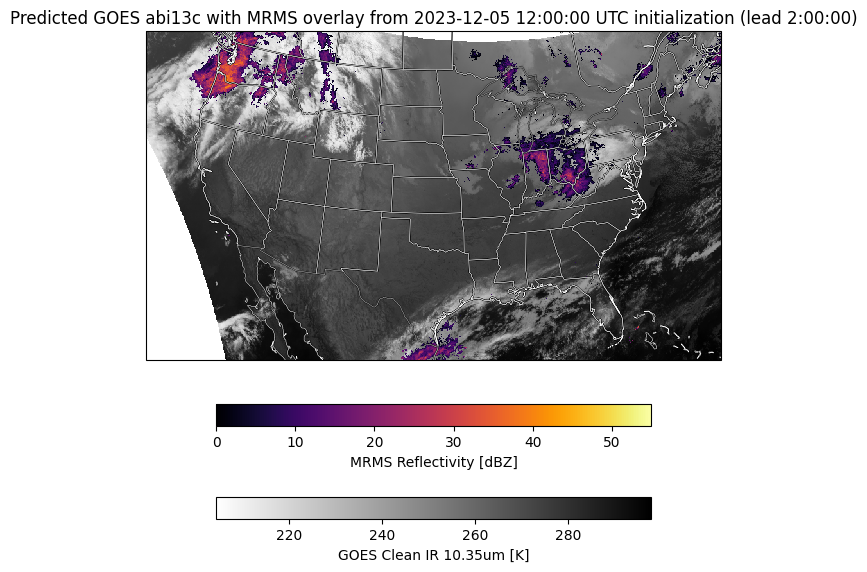

In [8]:
goes_channel = "abi13c"
goes_ch_idx = list(model.variables).index(goes_channel)
mrms_ch_idx = list(model_mrms.variables).index("refc")

# จุดกริดที่ไม่ถูกต้องของการเติมน่าน
y_pred = torch.where(model.valid_mask, y_pred, torch.nan)
y_mrms_pred = torch.where(model_mrms.valid_mask, y_mrms_pred, torch.nan)

# เตรียม HRRR Lambert Conformal projection
proj_hrrr = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)
plt.figure(figsize=(9, 6))
ax = plt.axes(projection=proj_hrrr)

# เส้นชายฝั่ง/รัฐสองชั้นเพื่อการมองเห็นที่ดีขึ้นทั้งกลางวันและกลางคืน
# รัศมีสีดำ (หนาขึ้น)
ax.coastlines(color="black", linewidth=1.2)
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.0)

# เส้นในสีขาว (ทินเนอร์)
ax.coastlines(color="white", linewidth=0.4)
ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=0.3)

field = y_pred[0, 0, 0, goes_ch_idx].detach().cpu().numpy()
im = ax.pcolormesh(
    lon_out,
    lat_out,
    field,
    transform=ccrs.PlateCarree(),
    cmap="gray_r",
    shading="auto",
)

# ซ้อนทับ MRMS ที่ด้านบนของ GOES
field_mrms = y_mrms_pred[0, 0, 0, mrms_ch_idx]
field_mrms = (
    torch.where(~model.valid_mask, torch.nan, field_mrms).detach().cpu().numpy()
)
field_mrms = np.where(field_mrms <= 0, np.nan, field_mrms)
im_mrms = ax.pcolormesh(
    lon_out,
    lat_out,
    field_mrms,
    transform=ccrs.PlateCarree(),
    cmap="inferno",
    shading="auto",
    vmin=0.0,
    vmax=55.0,
)
plt.colorbar(
    im,
    label="GOES Clean IR 10.35um [K]",
    orientation="horizontal",
    pad=0.05,
    shrink=0.5,
)
plt.colorbar(
    im_mrms,
    label="MRMS Reflectivity [dBZ]",
    orientation="horizontal",
    pad=0.1,
    shrink=0.5,
)

time = y_coords["time"][0].item()
lead_time = y_coords["lead_time"][0]
plt.title(
    f"Predicted GOES {goes_channel} with MRMS overlay from {time} UTC "
    f"initialization (lead {lead_time.astype('timedelta64[m]').item()})"
)

plt.tight_layout()
plt.savefig("outputs/20_stormscope_goes_example.png", dpi=300)